# Python Data visualization and manipulation
1. Easy problem : Import this data into a Python Dataframe
    a. Plot the same chart as you did in excel using your favourite plotting library
    b. create a 5 day moving average on the plot
    c. Use python Find local peaks and lows in the data . tabulated them
    d. Find out every instance the Voltage went below 20 and tabulate it

2. Bonus points : Find every instance where the downward slope      accelerates in each downward cycle and print the timestamp

3. Bonus points : Host this python code on your favourite hosting server

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

In [3]:
input_file="/content/drive/MyDrive/Greencell Internship Jul 2026- Assignment/Greencell Solution(in).csv"
MA_short=1000
MA_long=5000

## Import data


In [4]:
df=pd.read_csv(input_file)
print(df.head())

   Voltage         Timestamp  1000 Value MA  5000 Value MA  Unnamed: 4  \
0      100  26-06-2024 06:17  1001 Value MA  5001 Value MA         NaN   
1      100  26-06-2024 06:18  1002 Value MA  5002 Value MA         NaN   
2      100  26-06-2024 06:18  1003 Value MA  5003 Value MA         NaN   
3      100  26-06-2024 06:18  1004 Value MA  5004 Value MA         NaN   
4      100  26-06-2024 06:19  1005 Value MA  5005 Value MA         NaN   

   Unnamed: 5  Unnamed: 6 Unnamed: 7  
0         NaN         NaN        NaN  
1         NaN         NaN        NaN  
2         NaN         NaN        NaN  
3         NaN         NaN        NaN  
4         NaN         NaN        NaN  


In [5]:
df["1000 Value MA"]= df["Voltage"].rolling(window=MA_short).mean()
df["5000 Value MA"]= df["Voltage"].rolling(window=MA_long).mean()

## a. Same chart as excel

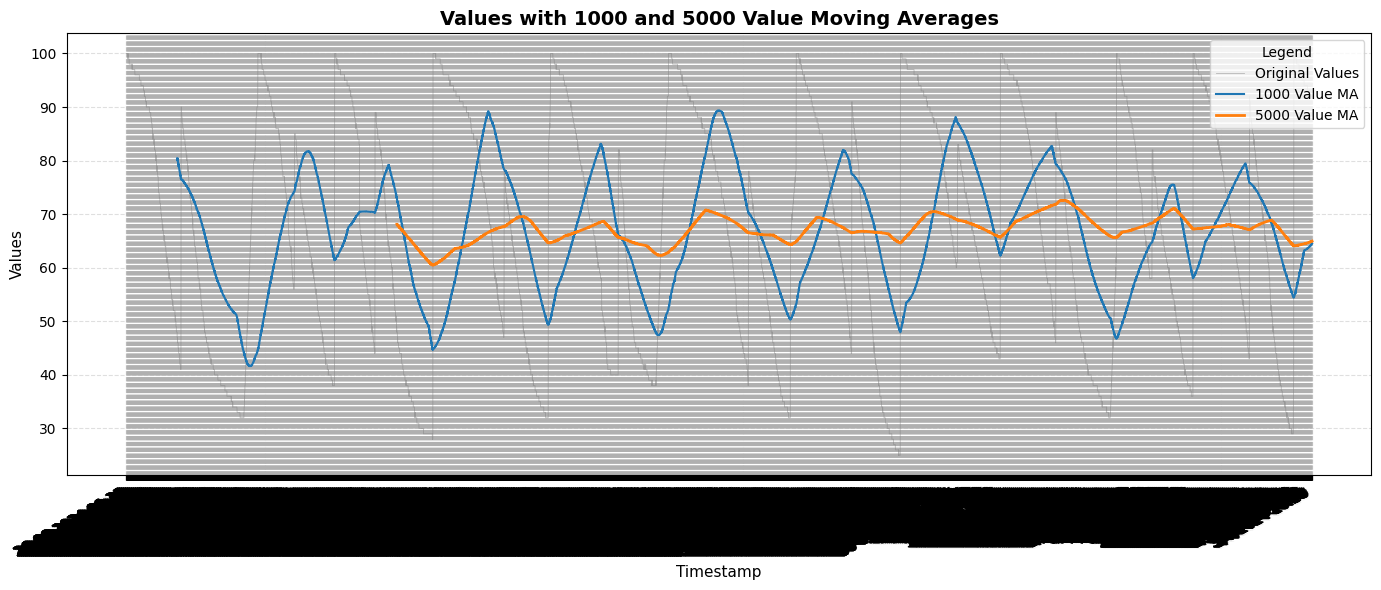

saved.


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Timestamp'], df['Voltage'], color='gray', linewidth=0.6, alpha=0.5, label='Original Values')
ax.plot(df['Timestamp'], df['1000 Value MA'], color='#1f77b4', linewidth=1.5, label='1000 Value MA')
ax.plot(df['Timestamp'], df['5000 Value MA'], color='#ff7f0e', linewidth=2.0, label='5000 Value MA')

ax.set_title('Values with 1000 and 5000 Value Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestamp', fontsize=11)
ax.set_ylabel('Values', fontsize=11)
ax.legend(title='Legend', loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('task1 moving averages.png', dpi=300)
plt.show()
plt.close()
print("saved.")


## b: Add a 5-Day Moving Average to the Plot


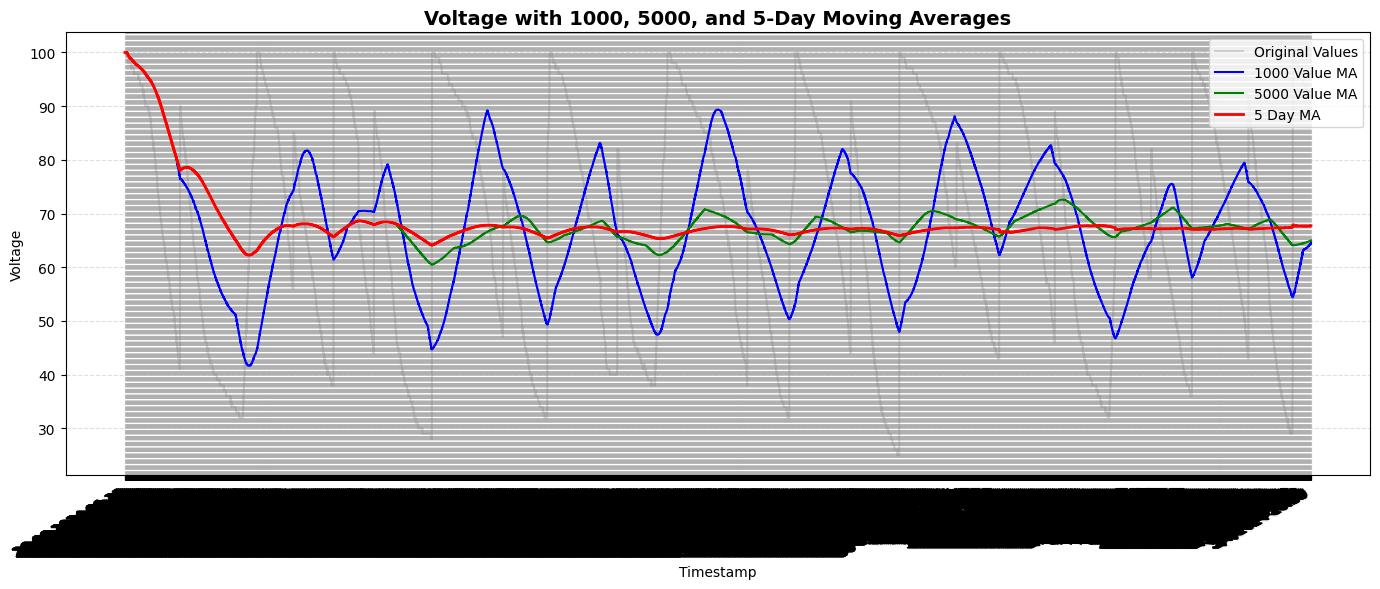

saved.


In [22]:
df['Timestamp_dt'] = pd.to_datetime(df['Timestamp'], dayfirst=True, format='mixed')
df = df.sort_values('Timestamp_dt')

# Computing 5day time based rolling average
df['5 Day MA'] = df.set_index('Timestamp_dt')['Voltage'].rolling('5D').mean().values

# original data + 1000 MA + 5000 MA + 5 Day MA
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['Timestamp'], df['Voltage'], color='gray', alpha=0.3, label='Original Values')
ax.plot(df['Timestamp'], df['1000 Value MA'], color='blue', label='1000 Value MA')
ax.plot(df['Timestamp'], df['5000 Value MA'], color='green', label='5000 Value MA')
ax.plot(df['Timestamp'], df['5 Day MA'], color='red', linewidth=2, label='5 Day MA')

ax.set_title('Voltage with 1000, 5000, and 5-Day Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Voltage')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('task2 5day moving average.png', dpi=300)
plt.show()
plt.close()
print("saved.")

## c: find local peaks and lows

In [19]:
voltage_val=df['Voltage'].values
Peak,_ =find_peaks(voltage_val, distance=100)
Low,_ =find_peaks(-voltage_val, distance=100)

Peak_df=pd.DataFrame({
    'Timestamp':df['Timestamp'][Peak],
    'Voltage':df['Voltage'][Peak],
    'Type':'Peak'
  })
Low_df=pd.DataFrame({
    'Timestamp':df['Timestamp'][Low],
    'Voltage':df['Voltage'][Low],
    'Type': 'Low'
  })

extrema_df = pd.concat([Peak_df, Low_df]).sort_index().reset_index(drop=True)
extrema_df.to_csv("task3 peaks and lows.csv", index=False)

print(f"Found {len(Peak_df)} local peaks and {len(Low_df)} local lows")
print("Saved: task3 peaks and lows.csv")
display(extrema_df)

Found 143 local peaks and 141 local lows
Saved: task3 peaks and lows.csv


,Timestamp,Voltage,Type
0,26-06-2024 09:42,98,Peak
1,26-06-2024 09:57,97,Low
2,26-06-2024 10:33,95,Peak
3,26-06-2024 10:41,95,Low
4,26-06-2024 11:08,90,Peak
...,...,...,...
279,2/7/2024 22:53,39,Low
280,2/7/2024 23:18,35,Peak
281,2/7/2024 23:35,33,Low
282,3/7/2024 0:13,29,Low


## # Find Instances Where Voltage < 20

In [16]:
below_20_voltage = df[df["Voltage"] < 20][["Timestamp", "Voltage"]].reset_index(drop=True)
below_20_voltage.to_csv("task4 below 20 voltage.csv", index=False)

if len(below_20_voltage) == 0:
    print("No instances found"
          f"(dataset minimum = {df['Voltage'].min()}).")
else:
    print(f"Found {len(below_20_voltage)} instances where Voltage went below 20")
print("Saved: task4 below 20 voltage.csv")



No instances found(dataset minimum = 25).
Saved: task4 below 20 voltage.csv


## Bonus1: Find downward slope acceleration

In [21]:
#1st derivative (slope) and 2nd derivative (acceleration)
df['slope'] = df['Voltage'].diff()
df['acceleration'] = df['slope'].diff()

# downward cycles (where slope < 0)
df['downward'] = df['slope'] < 0
df['cycle_id'] = (~df['downward']).cumsum()

# rows within downward cycles
downward_cycles = df[df['downward']].copy()

# timestamp of maximum downward acceleration (min acceleration value) per cycle
accelerating_points = downward_cycles.loc[
    downward_cycles.groupby('cycle_id')['acceleration'].idxmin()
][['Timestamp', 'Voltage', 'slope', 'acceleration']].reset_index(drop=True)

# 1-point fluctuations
accelerating_points = accelerating_points[accelerating_points['acceleration'] < -2]

accelerating_points.to_csv("task bonus accelerating downward.csv", index=False)
print(f"Found {len(accelerating_points)} downward cycles with slope acceleration:")
display(accelerating_points)

Found 13 downward cycles with slope acceleration:


,Timestamp,Voltage,slope,acceleration
159,26-06-2024 21:16,35,-1.0,-3.0
160,26-06-2024 21:22,41,-1.0,-3.0
171,26-06-2024 22:10,83,-1.0,-3.0
210,27-06-2024 01:39,68,-3.0,-3.0
313,27-06-2024 17:15,68,-15.0,-15.0
471,28-06-2024 13:49,62,-2.0,-3.0
611,29-06-2024 02:35,52,-5.0,-5.0
618,29-06-2024 03:11,43,-3.0,-3.0
627,29-06-2024 05:39,77,-3.0,-3.0
633,29-06-2024 06:07,68,-4.0,-4.0
